In [1]:
import watermark
pkg_versions = watermark.watermark(
    packages="requests,pandas,tqdm,geopandas")
print(pkg_versions)

requests : 2.32.5
pandas   : 1.5.3
tqdm     : 4.67.1
geopandas: 1.0.1



In [2]:
import pandas as pd
df = pd.read_csv("구군별 교통 접근성.csv")

In [3]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/home/DL/.local/share/fonts/KoPubWorld/KoPubWorld Dotum Medium.ttf"

# 현재 Python 프로세스에 폰트 등록
fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(fname=font_path).get_name()
print(font_name)

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

KoPubWorldDotum


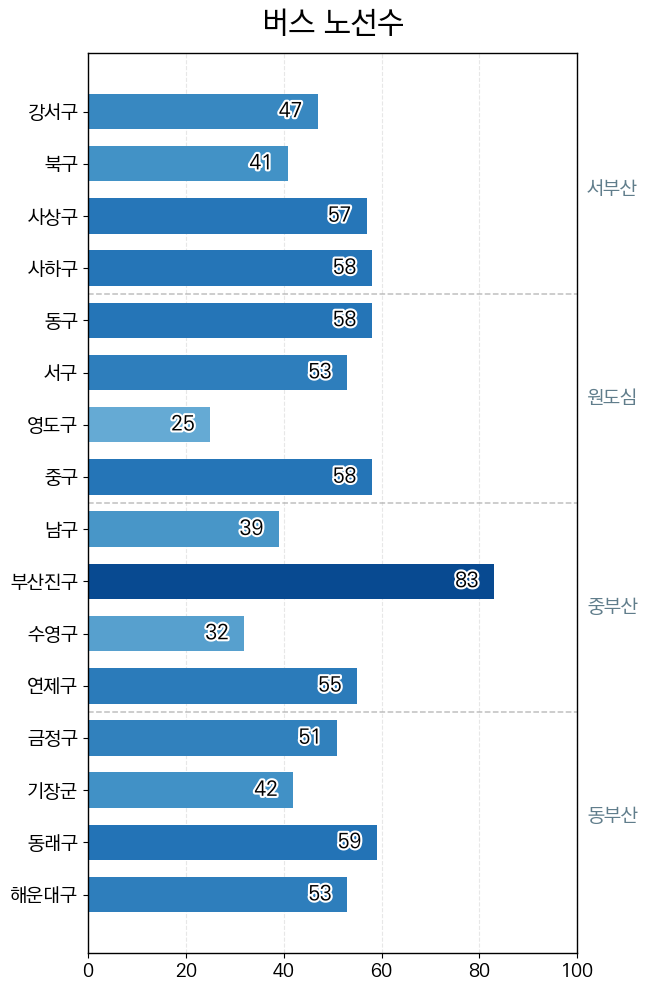

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe


# =========================================================
# 1. 구군 → 4개 권역
# =========================================================

region_map = {
    # 원도심
    "중구": "원도심",
    "동구": "원도심",
    "서구": "원도심",
    "영도구": "원도심",

    # 중부산
    "남구": "중부산",
    "부산진구": "중부산",
    "수영구": "중부산",
    "연제구": "중부산",

    # 서부산
    "강서구": "서부산",
    "북구": "서부산",
    "사상구": "서부산",
    "사하구": "서부산",

    # 동부산
    "금정구": "동부산",
    "기장군": "동부산",
    "동래구": "동부산",
    "해운대구": "동부산",
}


# =========================================================
# 2. 데이터 복사 + 권역 생성
# =========================================================

d = df.copy()
d["권역"] = d["구군"].map(region_map)


# =========================================================
# 3. 권역 순서
# =========================================================

region_order = [
    "서부산",
    "원도심",
    "중부산",
    "동부산"
]

d["권역"] = pd.Categorical(
    d["권역"],
    categories=region_order,
    ordered=True
)


# =========================================================
# 4. 권역 → 구군 가나다순
# =========================================================

d = (
    d
    .sort_values(
        ["권역", "구군"],
        ascending=[True, True]
    )
    .reset_index(drop=True)
)


# =========================================================
# 5. 막대 색상
# =========================================================

colors = plt.cm.Blues(
    0.35 + 0.55 * (
        d["노선수"] / d["노선수"].max()
    )
)


# =========================================================
# 6. 그래프
# =========================================================

fig, ax = plt.subplots(figsize=(7.5, 10))

y = np.arange(len(d))

bars = ax.barh(
    y,
    d["노선수"],
    color=colors,
    height=0.68
)


# =========================================================
# 7. Y축 구군명
# =========================================================

ax.set_yticks(y)

ax.set_yticklabels(
    d["구군"],
    fontsize=14
)

# 위 → 아래
# 서부산 → 원도심 → 중부산 → 동부산
ax.invert_yaxis()


# =========================================================
# 8. 막대 숫자
# =========================================================

labels = ax.bar_label(
    bars,
    padding=-28,
    fontsize=15,
    color="black",
    weight="bold"
)

for t in labels:
    t.set_path_effects([
        pe.Stroke(
            linewidth=3,
            foreground="white"
        ),
        pe.Normal()
    ])


# =========================================================
# 9. 권역 구분선 + 권역명
# =========================================================

for region in region_order:

    idx = d.index[
        d["권역"] == region
    ].tolist()

    if not idx:
        continue

    start = min(idx)
    end = max(idx)


    # 권역 사이 구분선
    if start > 0:
        ax.axhline(
            y=start - 0.5,
            color="#9E9E9E",
            linewidth=1.1,
            linestyle="--",
            alpha=0.65,
            zorder=0
        )


    # 권역명
    center = (start + end) / 2

    ax.text(
        1.02,
        center,
        region,

        transform=ax.get_yaxis_transform(),

        ha="left",
        va="center",

        fontsize=14,
        weight="bold",

        color="#607D8B"
    )


# =========================================================
# 10. X축 tick 간격 = 20
# =========================================================

max_value = d["노선수"].max()

# 20 단위로 올림
xmax = int(np.ceil(max_value / 20) * 20)

ax.set_xlim(0, xmax)

ax.set_xticks(
    np.arange(0, xmax + 1, 20)
)


# =========================================================
# 11. Grid
# =========================================================

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)


# =========================================================
# 12. 제목
# =========================================================

ax.set_title(
    "버스 노선수",
    fontsize=22,
    weight="bold",
    pad=15
)

ax.set_xlabel("")
ax.set_ylabel("")

ax.tick_params(
    axis="both",
    labelsize=14
)


# =========================================================
# 13. 바깥 테두리 유지
# =========================================================

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)


# =========================================================
# 14. 레이아웃
# =========================================================

# 오른쪽 권역명 공간 확보
plt.tight_layout(
    rect=[0, 0, 0.88, 1]
)


# =========================================================
# 15. 저장
# =========================================================

plt.savefig(
    "버스_노선수_권역별.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

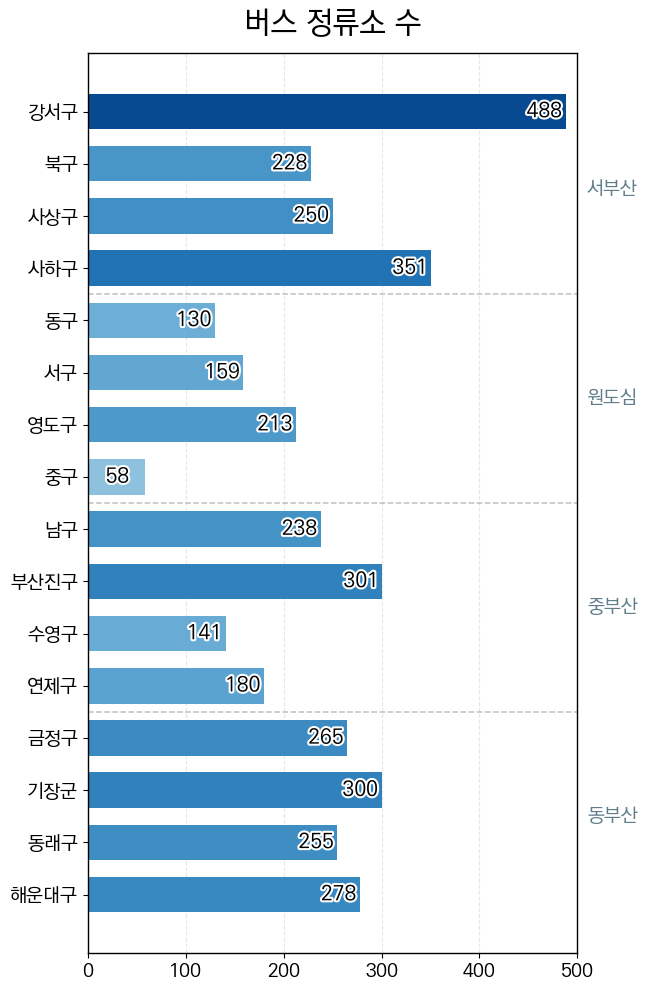

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe


# =========================================================
# 1. 구군 → 4개 권역
# =========================================================

region_map = {
    # 원도심
    "중구": "원도심",
    "동구": "원도심",
    "서구": "원도심",
    "영도구": "원도심",

    # 중부산
    "남구": "중부산",
    "부산진구": "중부산",
    "수영구": "중부산",
    "연제구": "중부산",

    # 서부산
    "강서구": "서부산",
    "북구": "서부산",
    "사상구": "서부산",
    "사하구": "서부산",

    # 동부산
    "금정구": "동부산",
    "기장군": "동부산",
    "동래구": "동부산",
    "해운대구": "동부산",
}


# =========================================================
# 2. 데이터 복사 + 권역 생성
# =========================================================

d = df.copy()
d["권역"] = d["구군"].map(region_map)


# =========================================================
# 3. 권역 순서
# =========================================================

region_order = [
    "서부산",
    "원도심",
    "중부산",
    "동부산"
]

d["권역"] = pd.Categorical(
    d["권역"],
    categories=region_order,
    ordered=True
)


# =========================================================
# 4. 권역 → 구군 가나다순
# =========================================================

d = (
    d
    .sort_values(
        ["권역", "구군"],
        ascending=[True, True]
    )
    .reset_index(drop=True)
)


# =========================================================
# 5. 막대 색상
# 정류소수가 많을수록 진하게
# =========================================================

colors = plt.cm.Blues(
    0.35 + 0.55 * (
        d["정류소수"] / d["정류소수"].max()
    )
)


# =========================================================
# 6. 그래프
# =========================================================

fig, ax = plt.subplots(figsize=(7.5, 10))

y = np.arange(len(d))

bars = ax.barh(
    y,
    d["정류소수"],
    color=colors,
    height=0.68
)


# =========================================================
# 7. Y축 구군명
# =========================================================

ax.set_yticks(y)

ax.set_yticklabels(
    d["구군"],
    fontsize=14
)

# 위 → 아래
# 서부산 → 원도심 → 중부산 → 동부산
ax.invert_yaxis()


# =========================================================
# 8. 막대 숫자
# =========================================================

labels = ax.bar_label(
    bars,
    padding=-28,
    fontsize=15,
    color="black",
    weight="bold"
)

for t in labels:
    t.set_path_effects([
        pe.Stroke(
            linewidth=3,
            foreground="white"
        ),
        pe.Normal()
    ])


# =========================================================
# 9. 권역 구분선 + 권역명
# =========================================================

for region in region_order:

    idx = d.index[
        d["권역"] == region
    ].tolist()

    if not idx:
        continue

    start = min(idx)
    end = max(idx)


    # -----------------------------------------------------
    # 권역 사이 점선
    # -----------------------------------------------------

    if start > 0:

        ax.axhline(
            y=start - 0.5,
            color="#9E9E9E",
            linewidth=1.1,
            linestyle="--",
            alpha=0.65,
            zorder=0
        )


    # -----------------------------------------------------
    # 오른쪽 권역명
    # -----------------------------------------------------

    center = (start + end) / 2

    ax.text(
        1.02,
        center,
        region,

        transform=ax.get_yaxis_transform(),

        ha="left",
        va="center",

        fontsize=14,
        weight="bold",
        color="#607D8B"
    )


# =========================================================
# 10. X축 tick 간격 = 20
# =========================================================

max_value = d["정류소수"].max()

xmax = int(
    np.ceil(max_value / 20) * 20
)

ax.set_xlim(
    0,
    xmax
)

ax.set_xticks(
    np.arange(
        0,
        xmax + 1,
        20
    )
)


# =========================================================
# 11. Grid
# =========================================================

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)


# =========================================================
# 12. 제목
# =========================================================

ax.set_title(
    "버스 정류소 수",
    fontsize=22,
    weight="bold",
    pad=15
)

ax.set_xlabel("")
ax.set_ylabel("")

ax.tick_params(
    axis="both",
    labelsize=14
)

tick_interval = 100

xmax = int(
    np.ceil(max_value / tick_interval) * tick_interval
)

ax.set_xlim(0, xmax)

ax.set_xticks(
    np.arange(0, xmax + 1, tick_interval)
)

# =========================================================
# 13. 바깥 테두리 유지
# =========================================================

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)


# =========================================================
# 14. 레이아웃
# =========================================================

# 오른쪽 권역명 공간 확보
plt.tight_layout(
    rect=[0, 0, 0.88, 1]
)


# =========================================================
# 15. 저장
# =========================================================

plt.savefig(
    "버스_정류소수_권역별.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

In [26]:
df.loc[df["구군"]=="강서구","지하철역수"] = 9
df.loc[df["구군"]=="기장군","지하철역수"] = 7

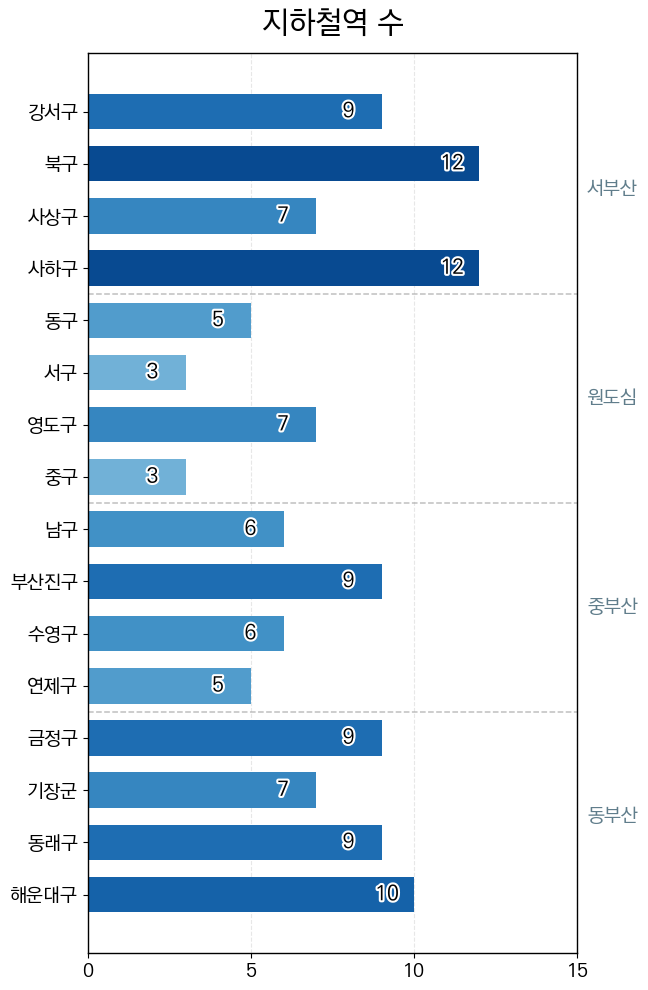

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe


# =========================================================
# 1. 구군 → 4개 권역
# =========================================================

region_map = {
    # 원도심
    "중구": "원도심",
    "동구": "원도심",
    "서구": "원도심",
    "영도구": "원도심",

    # 중부산
    "남구": "중부산",
    "부산진구": "중부산",
    "수영구": "중부산",
    "연제구": "중부산",

    # 서부산
    "강서구": "서부산",
    "북구": "서부산",
    "사상구": "서부산",
    "사하구": "서부산",

    # 동부산
    "금정구": "동부산",
    "기장군": "동부산",
    "동래구": "동부산",
    "해운대구": "동부산",
}


# =========================================================
# 2. 데이터 복사 + 권역 생성
# =========================================================

d = df.copy()
d["권역"] = d["구군"].map(region_map)


# =========================================================
# 3. 권역 순서
# =========================================================

region_order = [
    "서부산",
    "원도심",
    "중부산",
    "동부산"
]

d["권역"] = pd.Categorical(
    d["권역"],
    categories=region_order,
    ordered=True
)


# =========================================================
# 4. 권역 → 구군 가나다순
# =========================================================

d = (
    d
    .sort_values(
        ["권역", "구군"],
        ascending=[True, True]
    )
    .reset_index(drop=True)
)


# =========================================================
# 5. 막대 색상
# 지하철역수가 많을수록 진하게
# =========================================================

colors = plt.cm.Blues(
    0.35 + 0.55 * (
        d["지하철역수"] / d["지하철역수"].max()
    )
)


# =========================================================
# 6. 그래프
# =========================================================

fig, ax = plt.subplots(figsize=(7.5, 10))

y = np.arange(len(d))

bars = ax.barh(
    y,
    d["지하철역수"],
    color=colors,
    height=0.68
)


# =========================================================
# 7. Y축 구군명
# =========================================================

ax.set_yticks(y)

ax.set_yticklabels(
    d["구군"],
    fontsize=14
)

# 위 → 아래
# 서부산 → 원도심 → 중부산 → 동부산
ax.invert_yaxis()


# =========================================================
# 8. 막대 숫자
# =========================================================

labels = ax.bar_label(
    bars,
    padding=-28,
    fontsize=15,
    color="black",
    weight="bold"
)

for t in labels:
    t.set_path_effects([
        pe.Stroke(
            linewidth=3,
            foreground="white"
        ),
        pe.Normal()
    ])


# =========================================================
# 9. 권역 구분선 + 권역명
# =========================================================

for region in region_order:

    idx = d.index[
        d["권역"] == region
    ].tolist()

    if not idx:
        continue

    start = min(idx)
    end = max(idx)


    # 권역 사이 점선
    if start > 0:
        ax.axhline(
            y=start - 0.5,
            color="#9E9E9E",
            linewidth=1.1,
            linestyle="--",
            alpha=0.65,
            zorder=0
        )


    # 오른쪽 권역명
    center = (start + end) / 2

    ax.text(
        1.02,
        center,
        region,

        transform=ax.get_yaxis_transform(),

        ha="left",
        va="center",

        fontsize=14,
        weight="bold",
        color="#607D8B"
    )


# =========================================================
# 10. X축 tick 간격 = 5
# =========================================================

tick_interval = 5

max_value = d["지하철역수"].max()

xmax = int(
    np.ceil(max_value / tick_interval)
    * tick_interval
)

ax.set_xlim(
    0,
    xmax
)

ax.set_xticks(
    np.arange(
        0,
        xmax + 1,
        tick_interval
    )
)


# =========================================================
# 11. Grid
# =========================================================

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)


# =========================================================
# 12. 제목
# =========================================================

ax.set_title(
    "지하철역 수",
    fontsize=22,
    weight="bold",
    pad=15
)

ax.set_xlabel("")
ax.set_ylabel("")

ax.tick_params(
    axis="both",
    labelsize=14
)


# =========================================================
# 13. 바깥 테두리 유지
# =========================================================

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)


# =========================================================
# 14. 레이아웃
# =========================================================

plt.tight_layout(
    rect=[0, 0, 0.88, 1]
)


# =========================================================
# 15. 저장
# =========================================================

plt.savefig(
    "지하철역수_권역별.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

In [29]:
import geopandas as gpd

In [30]:
gdf = gpd.read_file("../sigungu/sig.shp", encoding="cp949")
gdf = gdf.set_crs(epsg=5179)
gdf = gdf.to_crs(4326)
gdf = gdf[[i[:2]=="26" for i in gdf["SIG_CD"]]].reset_index(drop=True)

In [31]:
gdf = gdf.merge(df, right_on = "구군", left_on="SIG_KOR_NM")
gdf

,SIG_CD,SIG_ENG_NM,SIG_KOR_NM,geometry,구군,노선수,정류소수,지하철역수
0,26110,Jung-gu,중구,"POLYGON ((129.03231 35.11643, 129.03235 35.116...",중구,58,58,3
1,26140,Seo-gu,서구,"MULTIPOLYGON (((129.01542 35.04808, 129.01515 ...",서구,53,159,3
2,26170,Dong-gu,동구,"POLYGON ((129.04264 35.14589, 129.04327 35.145...",동구,58,130,5
3,26200,Yeongdo-gu,영도구,"MULTIPOLYGON (((129.0932 35.03771, 129.09324 3...",영도구,25,213,7
4,26230,Busanjin-gu,부산진구,"POLYGON ((129.04001 35.19981, 129.04033 35.199...",부산진구,83,301,9
5,26260,Dongnae-gu,동래구,"POLYGON ((129.07905 35.22509, 129.0791 35.2250...",동래구,59,255,9
6,26290,Nam-gu,남구,"MULTIPOLYGON (((129.12702 35.09096, 129.12697 ...",남구,39,238,6
7,26320,Buk-gu,북구,"POLYGON ((128.98774 35.20145, 128.98774 35.201...",북구,41,228,12
8,26350,Haeundae-gu,해운대구,"MULTIPOLYGON (((129.13898 35.1586, 129.13963 3...",해운대구,53,278,10
9,26380,Saha-gu,사하구,"MULTIPOLYGON (((128.95195 34.88449, 128.95194 ...",사하구,58,351,12


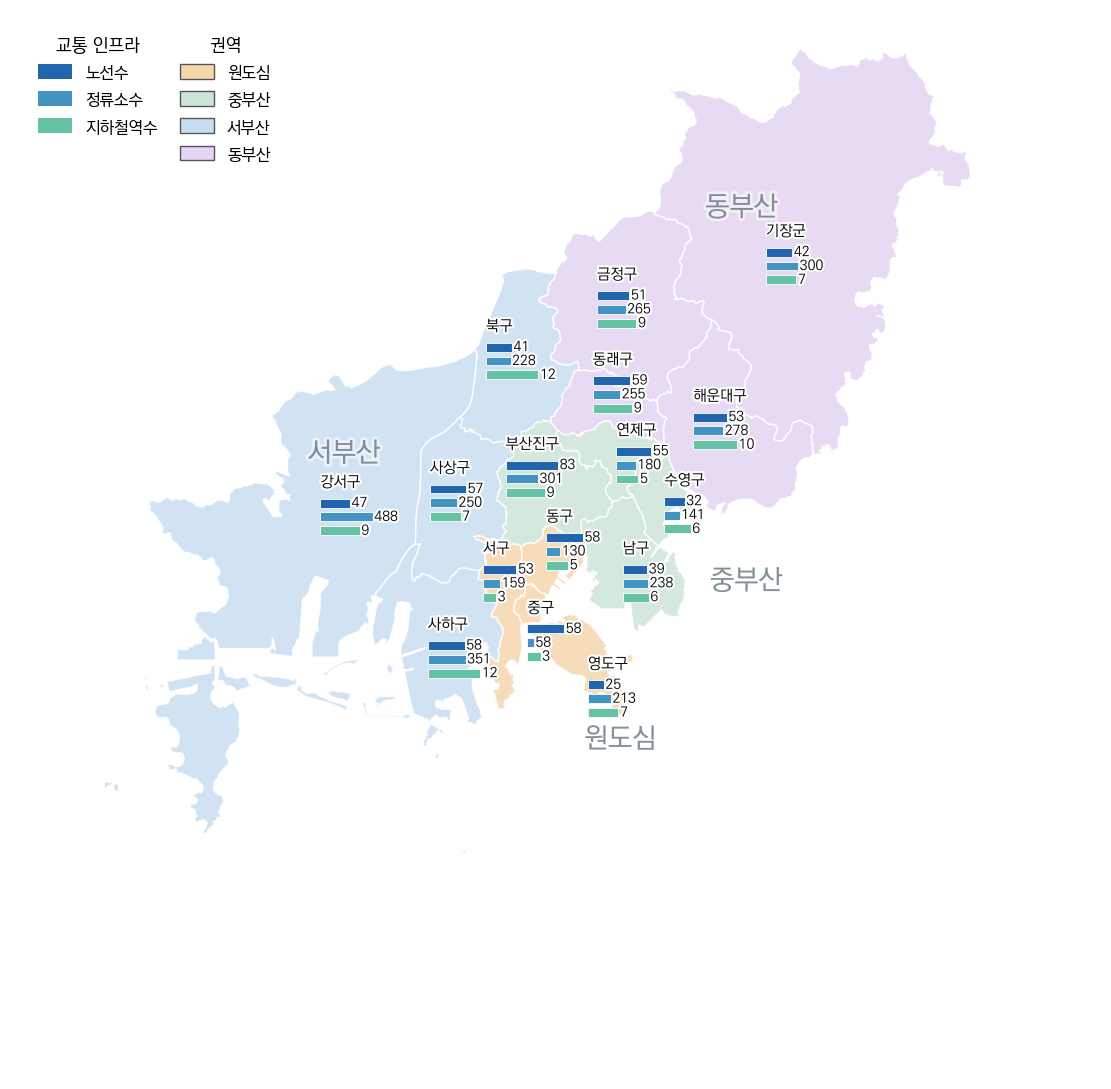

In [32]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Patch


# =========================================================
# 1. 4개 권역 설정
# =========================================================

region_map = {
    # 원도심
    "중구": "원도심",
    "동구": "원도심",
    "서구": "원도심",
    "영도구": "원도심",

    # 중부산
    "남구": "중부산",
    "부산진구": "중부산",
    "수영구": "중부산",
    "연제구": "중부산",

    # 서부산
    "강서구": "서부산",
    "북구": "서부산",
    "사상구": "서부산",
    "사하구": "서부산",

    # 동부산
    "금정구": "동부산",
    "기장군": "동부산",
    "동래구": "동부산",
    "해운대구": "동부산",
}


gdf = gdf.copy()
gdf["권역"] = gdf["구군"].map(region_map)


# =========================================================
# 2. 권역 geometry 생성
# =========================================================

region_gdf = (
    gdf
    .dissolve(by="권역")
    .reset_index()
)


# =========================================================
# 3. 권역 색상
# =========================================================

region_colors = {
    "원도심": "#F6D6AD",
    "중부산": "#CDE5D7",
    "서부산": "#C9DDF2",
    "동부산": "#E3D5F3",
}

gdf["권역색"] = gdf["권역"].map(region_colors)


# =========================================================
# 4. Plot
# =========================================================

fig, ax = plt.subplots(figsize=(18, 11))


# ---------------------------------------------------------
# 권역별 배경
# 구군 경계만 흰색으로 표시
# ---------------------------------------------------------

gdf.plot(
    ax=ax,
    color=gdf["권역색"],
    edgecolor="white",
    linewidth=1.1,
    alpha=0.85,
    zorder=1
)


# ---------------------------------------------------------
# 권역 외곽선은 표시하지 않음
# ---------------------------------------------------------

# region_gdf.boundary.plot(
#     ax=ax,
#     color="#455A64",
#     linewidth=2.7,
#     zorder=3
# )


# =========================================================
# 5. 지도 크기
# =========================================================

xmin, ymin, xmax, ymax = gdf.total_bounds

W = xmax - xmin
H = ymax - ymin


# =========================================================
# 6. 막대 설정
# =========================================================

cols = [
    "노선수",
    "정류소수",
    "지하철역수"
]

bar_colors = [
    "#2166AC",
    "#4393C3",
    "#66C2A4"
]

max_w = W * 0.06

bar_h = H * 0.009
gap   = H * 0.014


# 글자 흰색 외곽선
outline = [
    pe.Stroke(
        linewidth=3,
        foreground="white"
    ),
    pe.Normal()
]


# =========================================================
# 7. 구군별 막대 위치 보정
# =========================================================
#
# x
#   - : 왼쪽
#   + : 오른쪽
#
# y
#   - : 아래
#   + : 위
# =========================================================

offset = {

    # ---------- 중앙 ----------
    "부산진구": (-0.030,  0.018),
    "연제구":   ( 0.025,  0.010),
    "동래구":   ( 0.010,  0.030),

    # ---------- 동남부 ----------
    "수영구":   ( 0.030, -0.005),
    "남구":     ( 0.025, -0.005),
    "해운대구": ( 0.010,  0.000),

    # ---------- 원도심 ----------
    "동구":     ( 0.020,  0.025),
    "중구":     ( 0.025, -0.025),
    "서구":     (-0.005,  0.055),
    "영도구":   ( 0.030, -0.020),

    # ---------- 서부산 ----------
    "사상구":   (-0.005,  0.010),
    "사하구":   ( 0.010,  0.000),
    "북구":     (-0.005,  0.010),
    "강서구":   (-0.005,  0.000),

    # ---------- 동부산 ----------
    "금정구":   (-0.005,  0.010),
    "기장군":   ( 0.000,  0.000),
}


# =========================================================
# 8. 구군별 막대
# =========================================================

for _, row in gdf.iterrows():

    # Polygon 내부의 안정적인 위치
    p = row.geometry.representative_point()

    dx, dy = offset.get(
        row["구군"],
        (0, 0)
    )

    # 위치 보정
    cx = p.x + dx * W
    y0 = p.y + dy * H

    # 막대 시작 위치
    x0 = cx - max_w * 0.45


    # -----------------------------------------------------
    # 구군명
    # -----------------------------------------------------

    name = ax.text(
        x0,
        y0 + H * 0.014,

        row["구군"],

        ha="left",
        va="bottom",

        fontsize=11,
        weight="bold",

        color="#111",

        zorder=10
    )

    name.set_path_effects(outline)


    # -----------------------------------------------------
    # 가로 막대 3개
    # -----------------------------------------------------

    for i, (col, c) in enumerate(
        zip(cols, bar_colors)
    ):

        value = row[col]

        width = (
            value
            / gdf[col].max()
            * max_w
        )

        y = y0 - i * gap


        # 막대
        ax.barh(
            y,
            width,

            height=bar_h,
            left=x0,

            color=c,

            edgecolor="white",
            linewidth=0.6,

            zorder=5
        )


        # 숫자
        txt = ax.text(
            x0 + width + W * 0.002,
            y,

            f"{value}",

            ha="left",
            va="center",

            fontsize=10,
            weight="bold",

            color="#111",

            zorder=10
        )

        txt.set_path_effects(outline)


# =========================================================
# 9. 권역명 위치
# =========================================================

region_label_offset = {

    # 서부산
    "서부산": (
        -0.055,
         0.055
    ),

    # 중부산 - 오른쪽으로 이동
    "중부산": (
         0.155,
        -0.055
    ),

    # 동부산 - 오른쪽으로 이동
    "동부산": (
         0.035,
         0.075
    ),

    # 원도심
    "원도심": (
         0.040,
        -0.075
    ),
}


for _, row in region_gdf.iterrows():

    p = row.geometry.representative_point()

    dx, dy = region_label_offset.get(
        row["권역"],
        (0, 0)
    )

    x = p.x + dx * W
    y = p.y + dy * H


    txt = ax.text(
        x,
        y,

        row["권역"],

        ha="center",
        va="center",

        fontsize=20,
        weight="bold",

        color="#455A64",
        alpha=0.55,

        zorder=4
    )

    txt.set_path_effects([
        pe.Stroke(
            linewidth=4,
            foreground="white"
        ),
        pe.Normal()
    ])


# =========================================================
# 10. 범례
#
# 좌측 상단
#
# [ 교통 인프라 ]  [ 권역 ]
# =========================================================


# ---------------------------------------------------------
# 교통 인프라 범례
# ---------------------------------------------------------

transport_handles = [
    Patch(
        facecolor=c,
        edgecolor="none",
        label=label
    )
    for c, label in zip(
        bar_colors,
        [
            "노선수",
            "정류소수",
            "지하철역수"
        ]
    )
]


legend1 = ax.legend(
    handles=transport_handles,

    loc="upper left",

    # ★ 좌측 상단
    bbox_to_anchor=(
        0.02,
        0.98
    ),

    frameon=False,

    fontsize=12,

    title="교통 인프라",
    title_fontsize=13,

    handlelength=2.0,
    handleheight=1.0,

    labelspacing=0.6,

    borderaxespad=0
)

# 두 번째 legend 생성 시
# 첫 번째 legend가 사라지지 않도록 유지
ax.add_artist(legend1)


# ---------------------------------------------------------
# 권역 범례
# ---------------------------------------------------------

region_handles = [
    Patch(
        facecolor=color,

        edgecolor="#555",
        linewidth=1,

        label=region
    )

    for region, color
    in region_colors.items()
]


legend2 = ax.legend(
    handles=region_handles,

    loc="upper left",

    # ★ 교통 인프라 바로 오른쪽
    bbox_to_anchor=(
        0.15,
        0.98
    ),

    frameon=False,

    fontsize=12,

    title="권역",
    title_fontsize=13,

    handlelength=2.0,
    handleheight=1.0,

    labelspacing=0.6,

    borderaxespad=0
)


# =========================================================
# 11. 마무리
# =========================================================

ax.axis("off")


# =========================================================
# 12. 지도 여백
# =========================================================

ax.set_xlim(
    xmin - W * 0.10,
    xmax + W * 0.15
)

ax.set_ylim(
    ymin - H * 0.04,
    ymax + H * 0.04
)


# =========================================================
# 13. 레이아웃
# =========================================================

plt.tight_layout()


# =========================================================
# 14. 저장
# =========================================================

plt.savefig(
    "부산_교통인프라_4권역.png",

    dpi=300,

    bbox_inches="tight",

    transparent=True
)


plt.show()